In [295]:
import numpy as np
from scipy import signal, fft
import matplotlib.pyplot as plt

In [296]:
n = 500
Fs = 1000
F_max = 9
a = 0
b = 10

random = np.random.normal(a, b, n)
t = np.arange(n)/Fs

In [297]:
w = F_max/(Fs/2)
parameters_filter = signal.butter(3, w, 'low', output='sos')
filtered_signal = signal.sosfiltfilt(parameters_filter, random)

In [298]:
def showResults(x, y, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(32 / 2.54, 18 / 2.54))
    ax.plot(x, y, linewidth=2)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=14)
    plt.grid()
    plt.savefig('./figures/' + title + '.png', dpi=600)

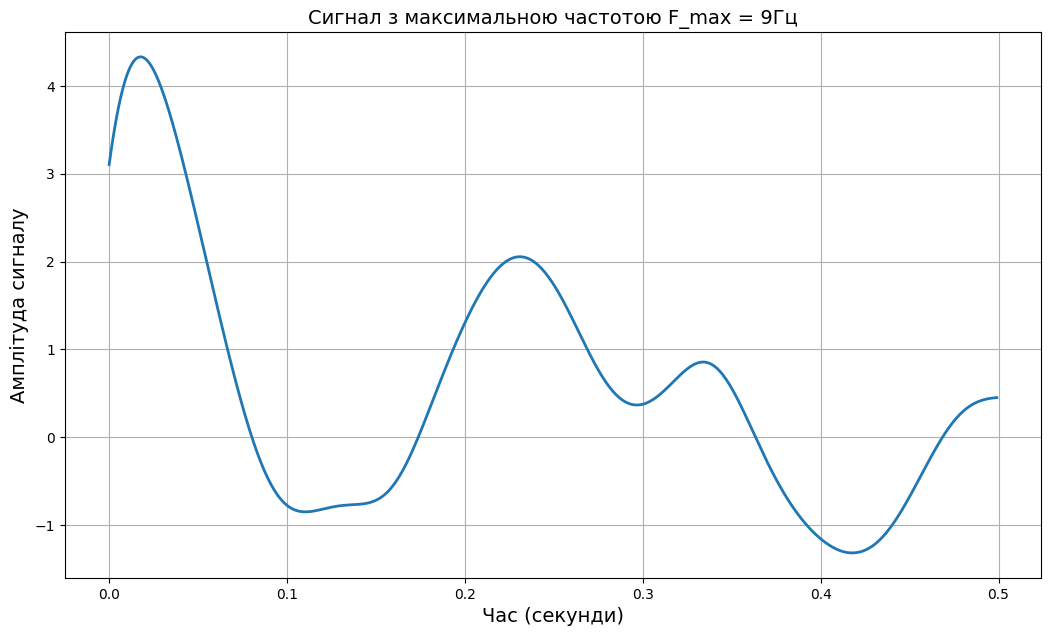

In [299]:
showResults(t, filtered_signal, 'Сигнал з максимальною частотою F_max = 9Гц' , 'Час (секунди)', 'Амплітуда сигналу')

In [300]:
spectrum = fft.fft(filtered_signal)
spectrum = np.abs(fft.fftshift(spectrum))
ticks = fft.fftfreq(n, 1 / n)
ticks = fft.fftshift(ticks)

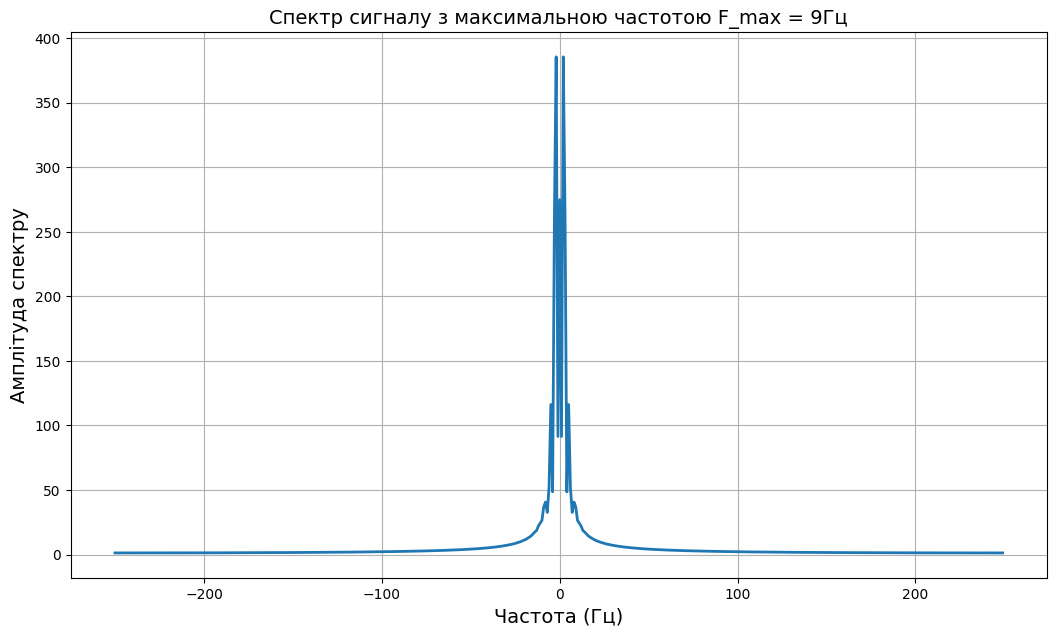

In [301]:
showResults(ticks, spectrum, 'Спектр сигналу з максимальною частотою F_max = 9Гц', 'Частота (Гц)', 'Амплітуда спектру')

In [302]:
F_filter = 16
w = F_filter/(Fs/2)
var_filtered_signal = np.var(filtered_signal)

discrete_signals = []
discrete_spectrums = []
discrete_filtered_signals = []
vars_discrete_filtered_signal = []
signal_noise = []

for Dt in [2, 4, 8, 16]:
    discrete_signal = np.zeros(n)
    for i in range(0, round(n / Dt)):
        discrete_signal[i * Dt] = filtered_signal[i * Dt]
    discrete_signals += [list(discrete_signal)]
    
    discrete_spectrum = fft.fft(discrete_signal)
    discrete_spectrum = np.abs(fft.fftshift(discrete_spectrum))
    discrete_spectrums += [list(discrete_spectrum)]

    parameters_filter = signal.butter(3, w, 'low', output='sos')
    discrete_filtered_signal = signal.sosfiltfilt(parameters_filter, discrete_signal)
    discrete_filtered_signals += [list(discrete_filtered_signal)]

    E1 = discrete_filtered_signal - filtered_signal
    var_discrete_filtered_signal = np.var(E1)
    vars_discrete_filtered_signal += [var_discrete_filtered_signal]
    signal_noise += [var_filtered_signal / var_discrete_filtered_signal]

In [303]:
def displayResultsSubplots(x, y, xlabel, ylabel, title):
    fig, ax = plt.subplots(2, 2, figsize=(21 / 2.54, 14 / 2.54))

    s = 0
    for i in range(0, 2):
        for j in range(0, 2):
            ax[i][j].plot(x, y[s], linewidth=1)
            s += 1

    fig.supxlabel(xlabel, fontsize=14)
    fig.supylabel(ylabel, fontsize=14)
    fig.suptitle(title, fontsize=14)
    fig.savefig('./figures/' + title + '.png', dpi=600)

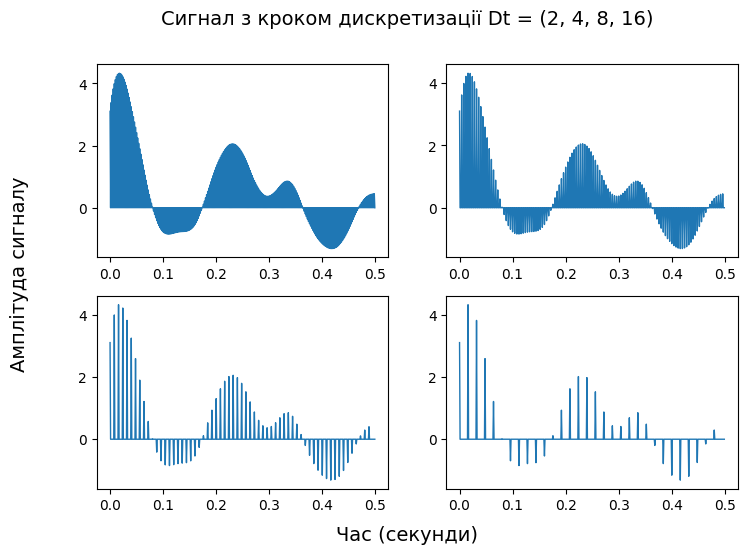

In [304]:
displayResultsSubplots(t, discrete_signals, 'Час (секунди)', 'Амплітуда сигналу', 'Сигнал з кроком дискретизації Dt = (2, 4, 8, 16)')

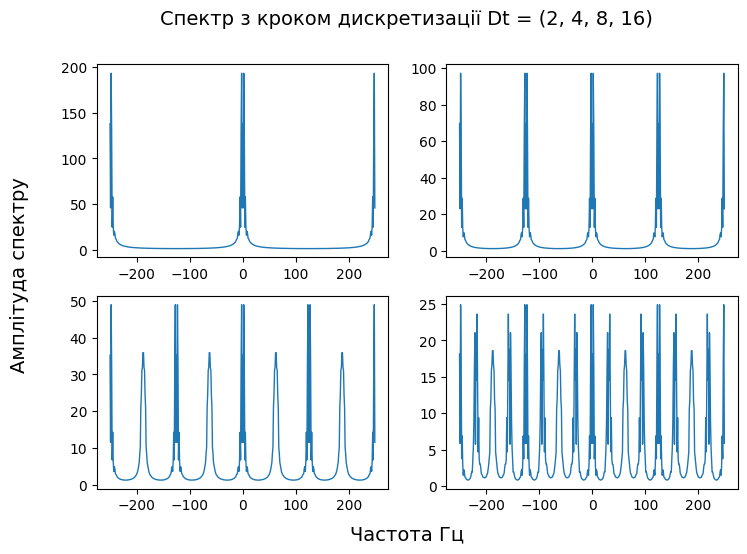

In [305]:
displayResultsSubplots(ticks , discrete_spectrums, 'Частота Гц', 'Амплітуда спектру', 'Спектр з кроком дискретизації Dt = (2, 4, 8, 16)')

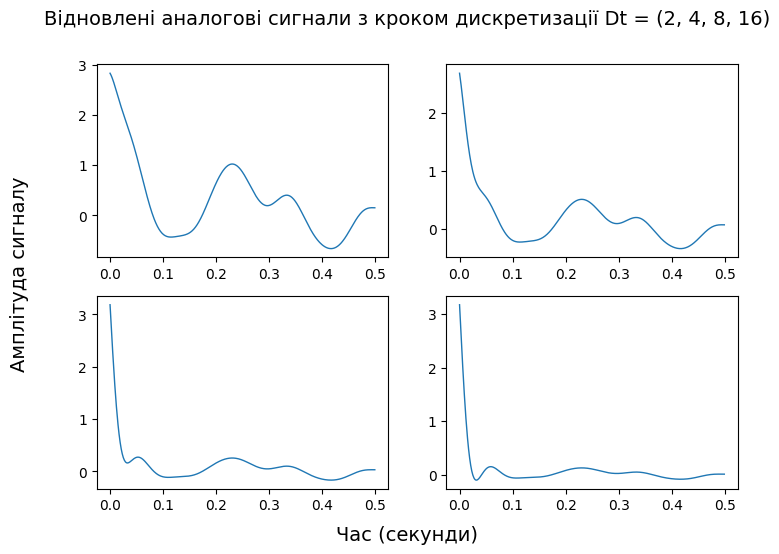

In [306]:
displayResultsSubplots(t , discrete_filtered_signals, 'Час (секунди)', 'Амплітуда сигналу', 'Відновлені аналогові сигнали з кроком дискретизації Dt = (2, 4, 8, 16)')

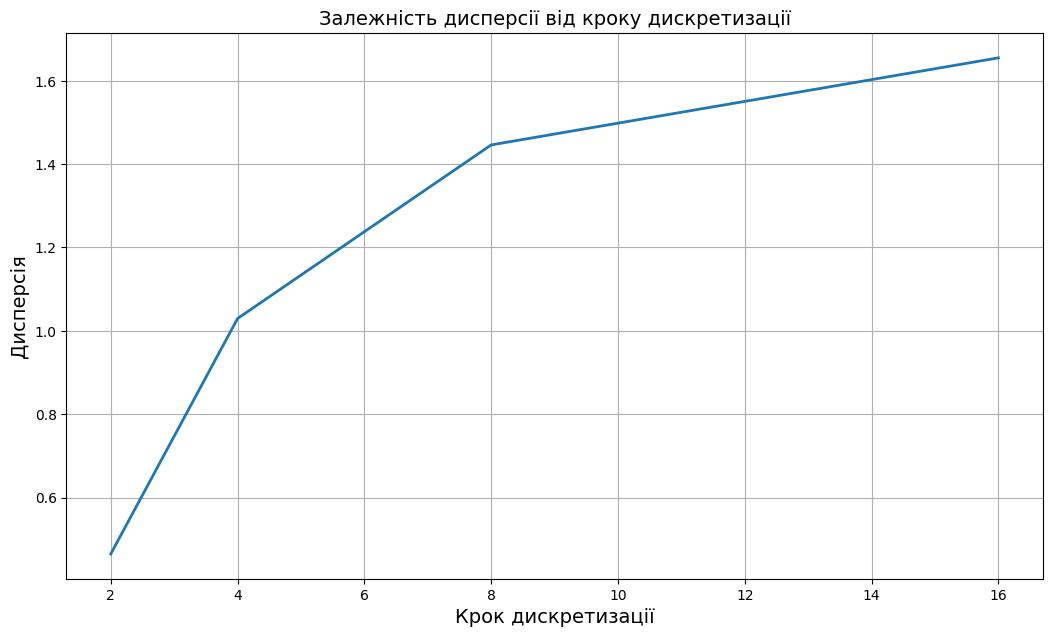

In [307]:
x = [2, 4, 8, 16]
showResults(x, vars_discrete_filtered_signal, 'Залежність дисперсії від кроку дискретизації', 'Крок дискретизації', 'Дисперсія')

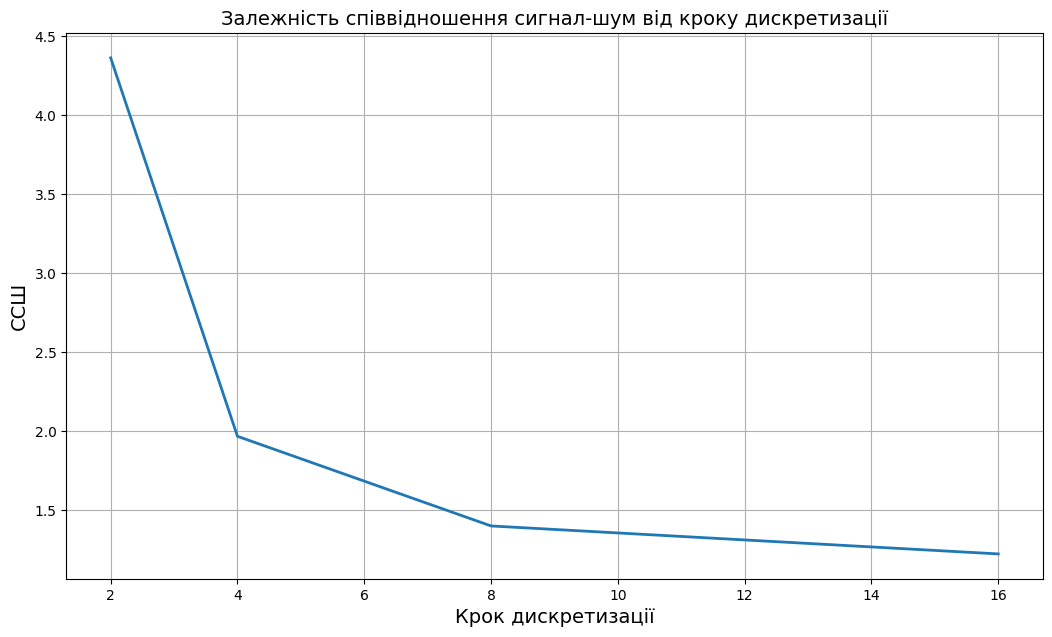

In [308]:
showResults(x, signal_noise, 'Залежність співвідношення сигнал-шум від кроку дискретизації', 'Крок дискретизації', 'CCШ')

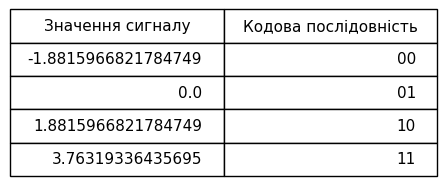

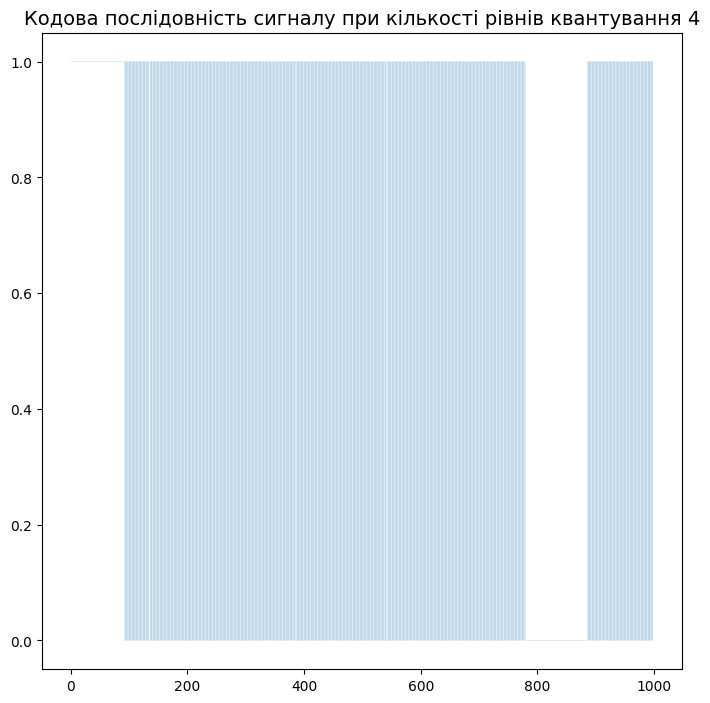

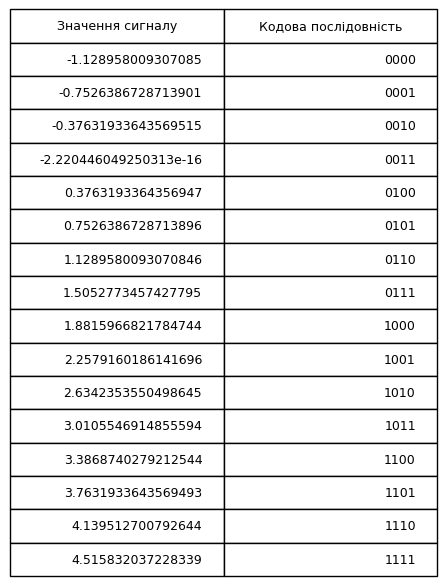

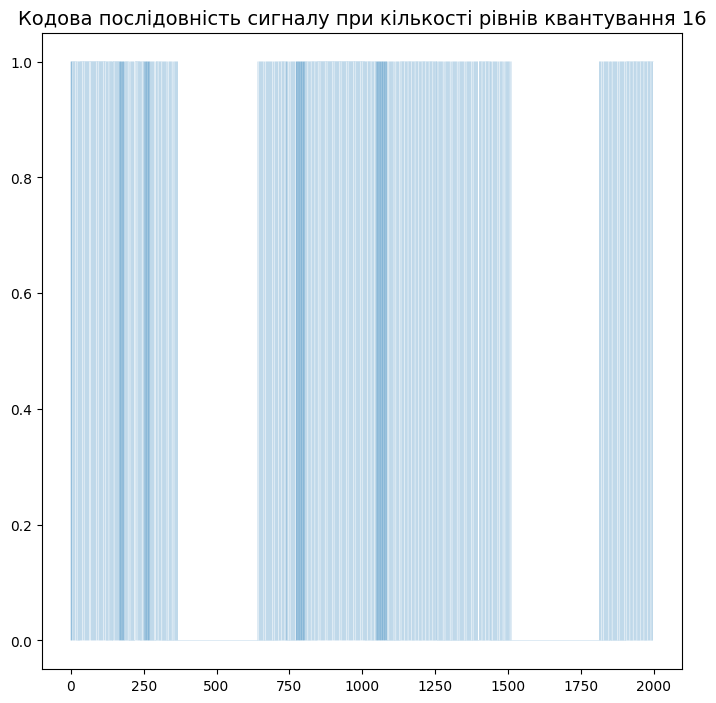

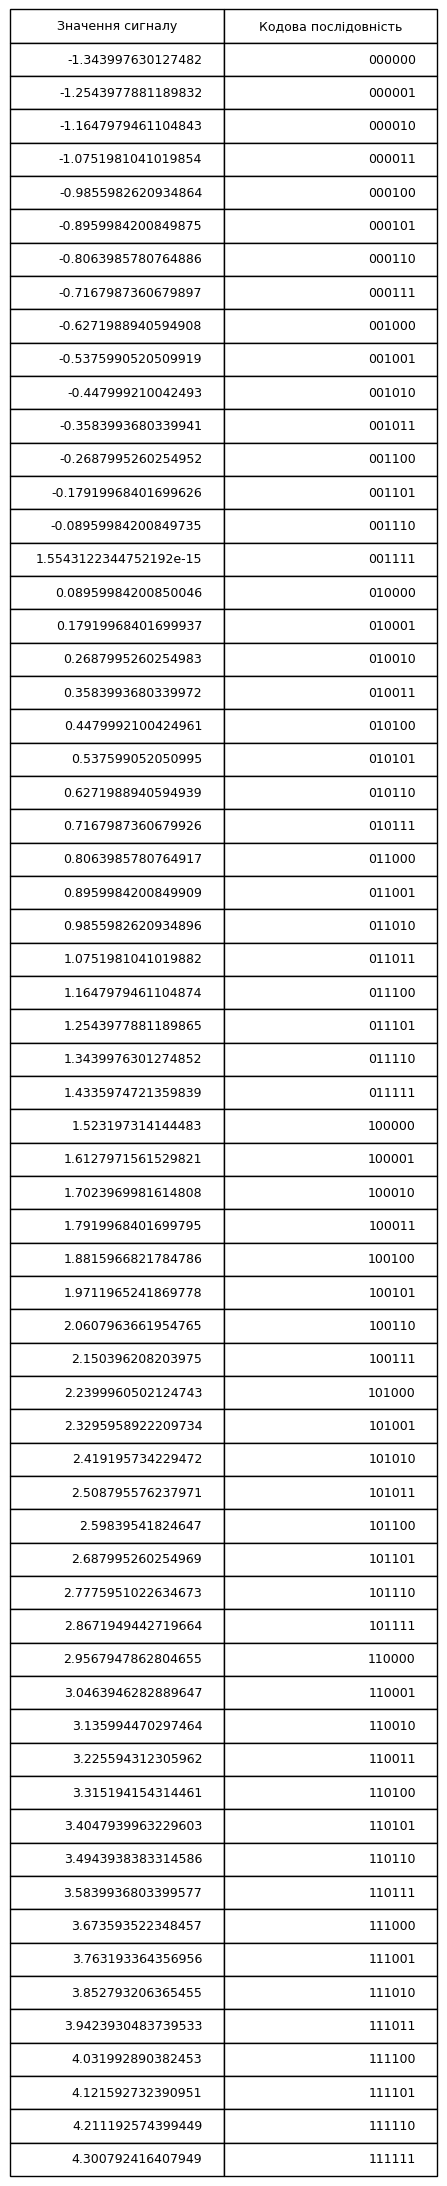

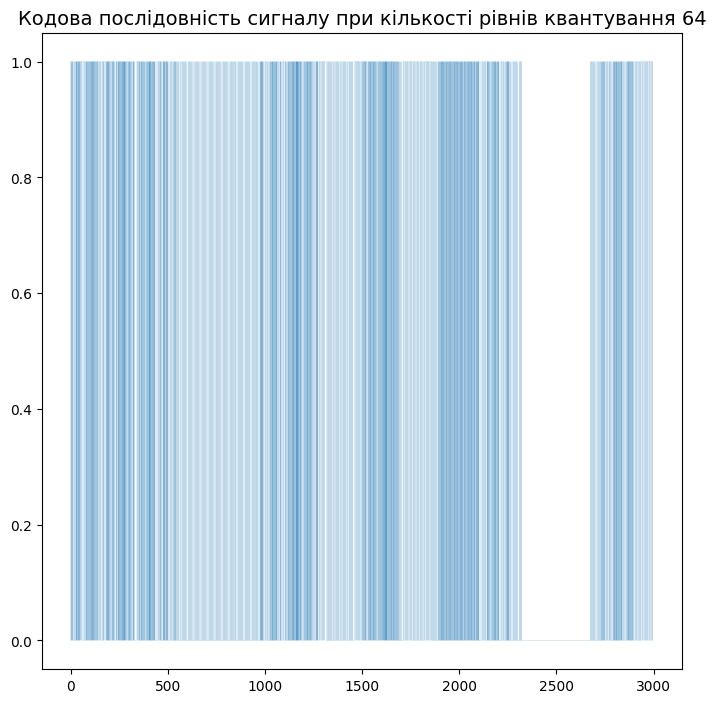

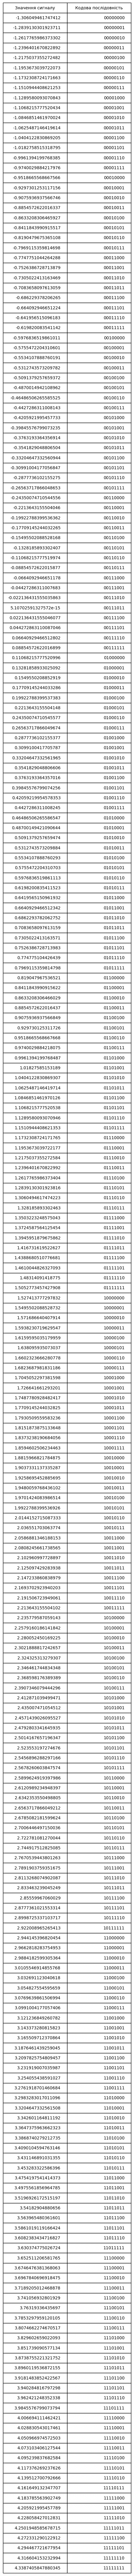

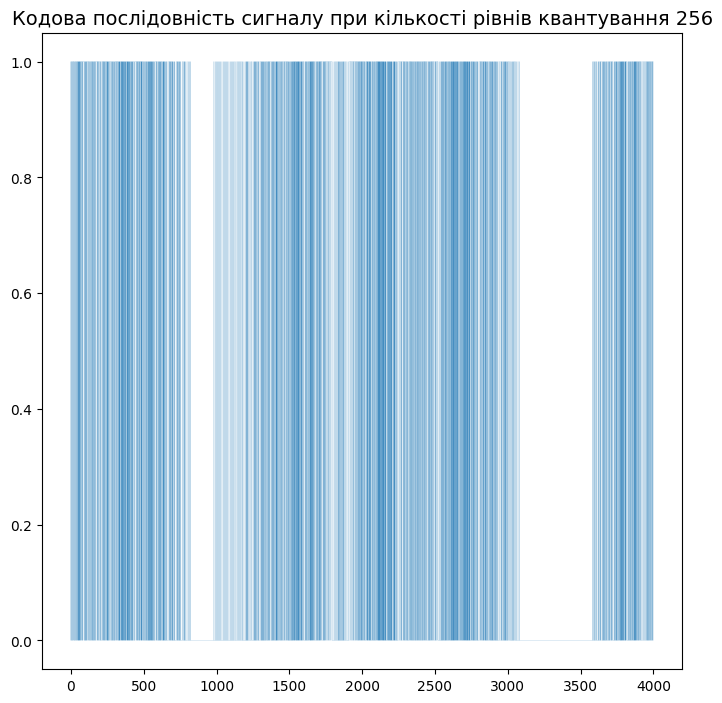

In [309]:
quantize_signals = []
vars_quantize_signal = []
signal_noise = []

for M in [4, 16, 64, 256]:
    delta = (np.max(filtered_signal) - np.min(filtered_signal)) / (M - 1)
    quantize_signal = delta * np.round(filtered_signal / delta)
    quantize_levels = np.arange(np.min(quantize_signal), np.max(quantize_signal) + 1, delta)
    quantize_bit = np.arange(0, M)
    quantize_bit = [format(bits, '0' + str(int(np.log(M) / np.log(2))) + 'b') for bits in quantize_bit]
    quantize_table = np.c_[quantize_levels[:M], quantize_bit[:M]]

    fig, ax = plt.subplots(figsize=(14 / 2.54, M / 2.54))
    table = ax.table(cellText=quantize_table, colLabels=['Значення сигналу', 'Кодова послідовність'], loc='center')
    table.set_fontsize(14)
    table.scale(1, 2)
    ax.axis('off')
    fig.savefig('./figures/Таблиця квантування для ' + str(M) + ' рівнів.png', dpi=600)

    bits = []
    for signal_value in quantize_signal:
        for index, value in enumerate(quantize_levels[:M]):
            if np.round(np.abs(signal_value-value), 0) == 0:
                bits.append(quantize_bit[index])
                break
    bits = [int(item) for item in list(''.join(bits))]
    fig, ax = plt.subplots(figsize=(21 / 2.54, 21 / 2.54))
    ax.step(np.arange(0, len(bits)), bits, linewidth=0.1)
    plt.title('Кодова послідовність сигналу при кількості рівнів квантування ' + str(M), fontsize=14)
    fig.savefig('./figures/Кодова послідовність сигналу при кількості рівнів квантування ' + str(M) + '.png', dpi=600)

    quantize_signals += [list(quantize_signal)]

    E1 = quantize_signal - filtered_signal
    var_quantize_signal = np.var(E1)
    vars_quantize_signal += [var_quantize_signal]
    signal_noise += [var_filtered_signal / var_quantize_signal]

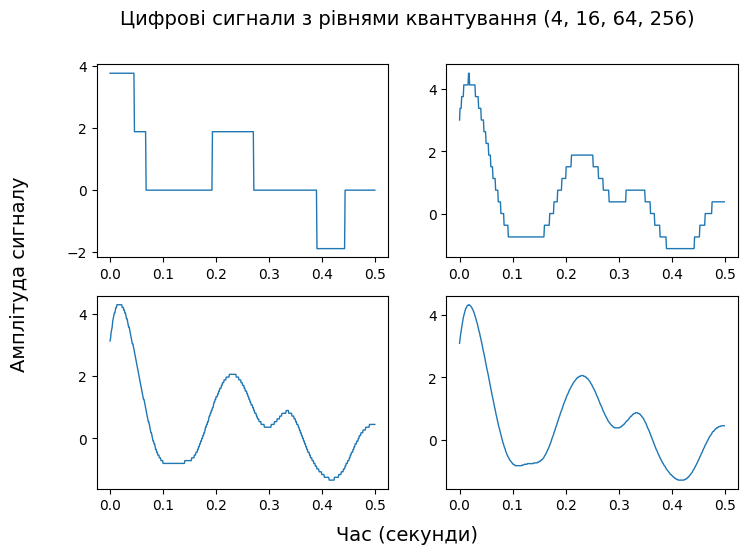

In [310]:
displayResultsSubplots(t , quantize_signals, 'Час (секунди)', 'Амплітуда сигналу', 'Цифрові сигнали з рівнями квантування (4, 16, 64, 256)')

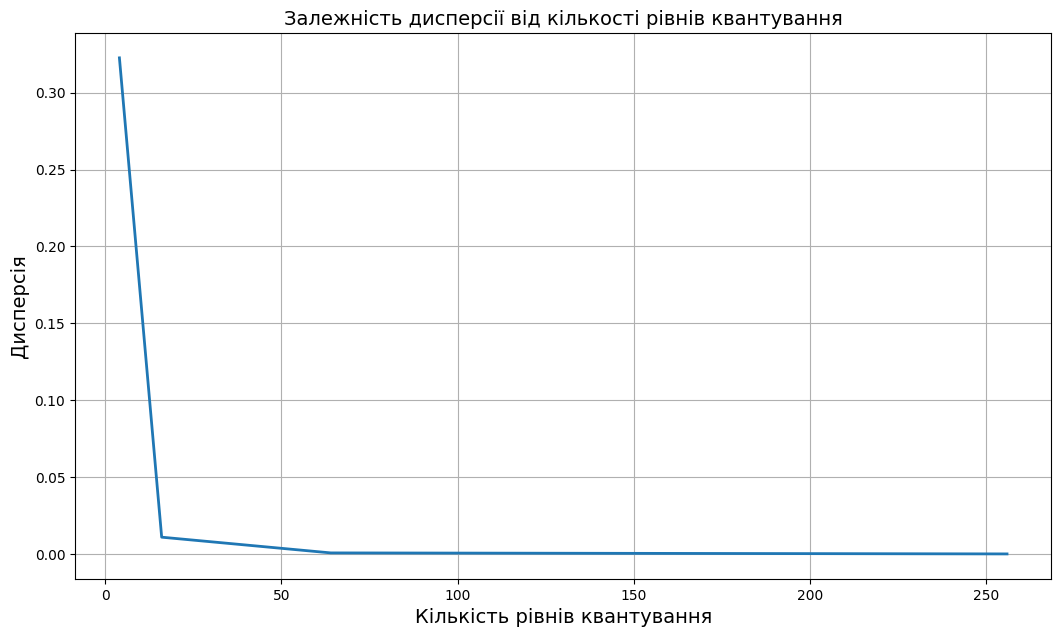

In [311]:
x = [4, 16, 64, 256]
showResults(x, vars_quantize_signal, 'Залежність дисперсії від кількості рівнів квантування', 'Кількість рівнів квантування', 'Дисперсія')

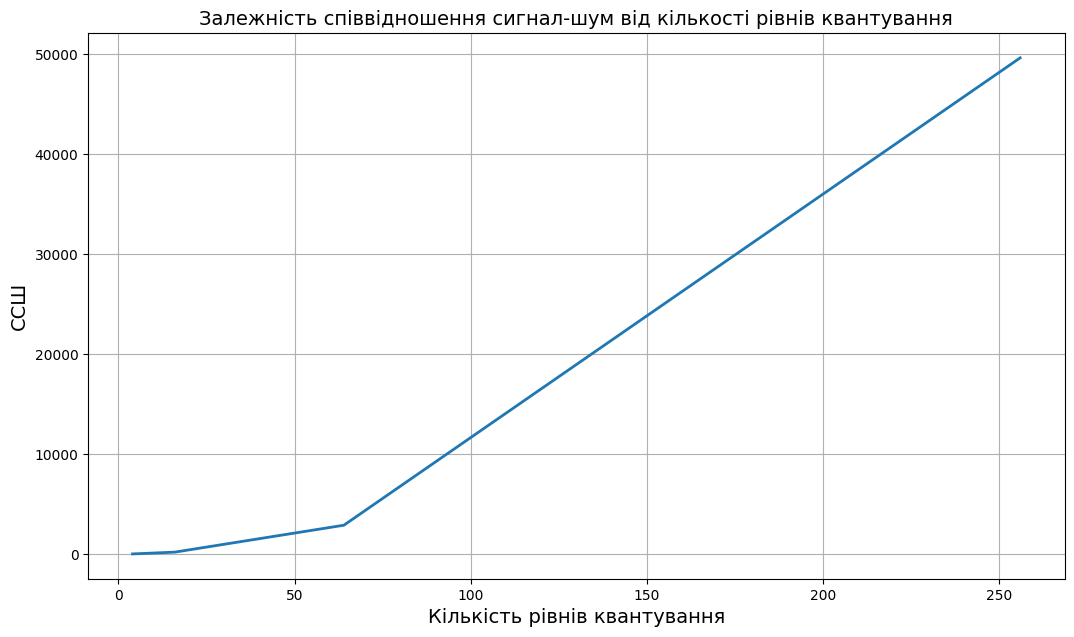

In [312]:
showResults(x, signal_noise, 'Залежність співвідношення сигнал-шум від кількості рівнів квантування', 'Кількість рівнів квантування', 'CCШ')